Exp 4

In [ ]:
import pandas as pd

df = pd.read_csv("/content/realistic_phishing_dataset.csv")
df.head()


,timestamp,url,url_length,dot_count,has_https,has_ip,contains_sensitive_word,label
0,13-02-2026 10:01,https://google.com/home,24,1,1,0,0,0
1,13-02-2026 10:02,https://amazon.in/login,26,1,1,0,1,0
2,13-02-2026 10:03,https://flipkart.com/account,30,1,1,0,1,0
3,13-02-2026 10:04,https://github.com/settings,27,1,1,0,0,0
4,13-02-2026 10:06,https://microsoft.com/security,30,1,1,0,1,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   timestamp                50 non-null     object
 1   url                      50 non-null     object
 2   url_length               50 non-null     int64 
 3   dot_count                50 non-null     int64 
 4   has_https                50 non-null     int64 
 5   has_ip                   50 non-null     int64 
 6   contains_sensitive_word  50 non-null     int64 
 7   label                    50 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 3.3+ KB


,0
timestamp,0
url,0
url_length,0
dot_count,0
has_https,0
has_ip,0
contains_sensitive_word,0
label,0


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.dtypes


/tmp/ipython-input-4245748343.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')


,0
timestamp,datetime64[ns]
url,object
url_length,int64
dot_count,int64
has_https,int64
has_ip,int64
contains_sensitive_word,int64
label,int64


In [ ]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


Before removing duplicates: (50, 8)
After removing duplicates: (50, 8)


In [ ]:
df.isnull().sum()

# If any missing values appear:
df = df.dropna()


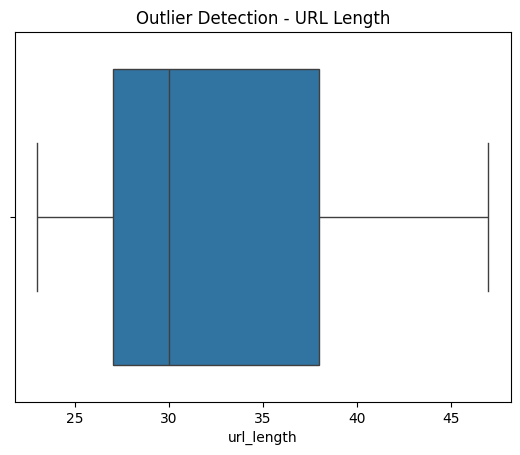

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.boxplot(x=df['url_length'])
plt.title("Outlier Detection - URL Length")
plt.show()


In [ ]:
# Count special characters
df['special_char_count'] = df['url'].str.count(r'[@\-_=]')

df.head()


,timestamp,url,url_length,dot_count,has_https,has_ip,contains_sensitive_word,label,special_char_count
0,2026-02-13 10:01:00,https://google.com/home,24,1,1,0,0,0,0
1,2026-02-13 10:02:00,https://amazon.in/login,26,1,1,0,1,0,0
2,2026-02-13 10:03:00,https://flipkart.com/account,30,1,1,0,1,0,0
3,2026-02-13 10:04:00,https://github.com/settings,27,1,1,0,0,0,0
4,2026-02-13 10:06:00,https://microsoft.com/security,30,1,1,0,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_features = ['url_length', 'dot_count', 'special_char_count']
df[num_features] = scaler.fit_transform(df[num_features])

df.head()


,timestamp,url,url_length,dot_count,has_https,has_ip,contains_sensitive_word,label,special_char_count
0,2026-02-13 10:01:00,https://google.com/home,-1.222934,-0.7269,1,0,0,0,-0.759257
1,2026-02-13 10:02:00,https://amazon.in/login,-0.913330,-0.7269,1,0,1,0,-0.759257
2,2026-02-13 10:03:00,https://flipkart.com/account,-0.294123,-0.7269,1,0,1,0,-0.759257
3,2026-02-13 10:04:00,https://github.com/settings,-0.758528,-0.7269,1,0,0,0,-0.759257
4,2026-02-13 10:06:00,https://microsoft.com/security,-0.294123,-0.7269,1,0,1,0,-0.759257


In [ ]:
df['label'].value_counts()

,count
label,
0,28
1,22


In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(analyzer='char', ngram_range=(3,5))
X_text = vectorizer.fit_transform(df['url'])
print("Text Feature Shape:", X_text.shape)

Text Feature Shape: (50, 1463)


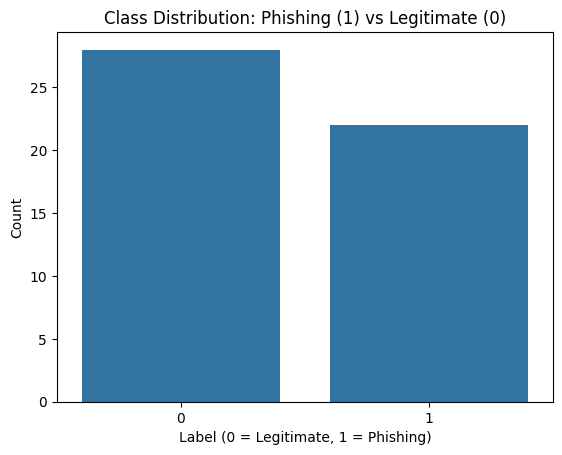

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(x='label', data=df)
plt.title("Class Distribution: Phishing (1) vs Legitimate (0)")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Count")
plt.show()


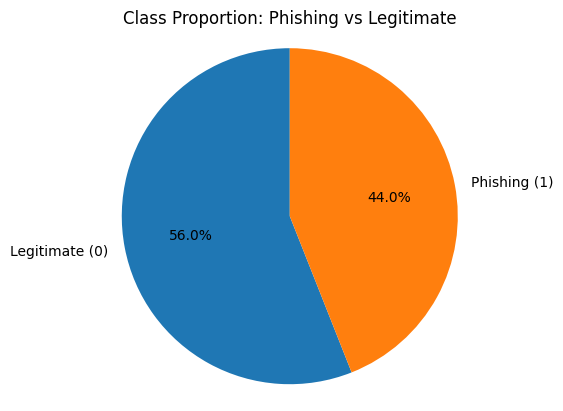

In [ ]:
labels = df['label'].value_counts()

plt.figure()
plt.pie(labels, labels=['Legitimate (0)', 'Phishing (1)'], autopct='%1.1f%%', startangle=90)
plt.title("Class Proportion: Phishing vs Legitimate")
plt.axis('equal')
plt.show()


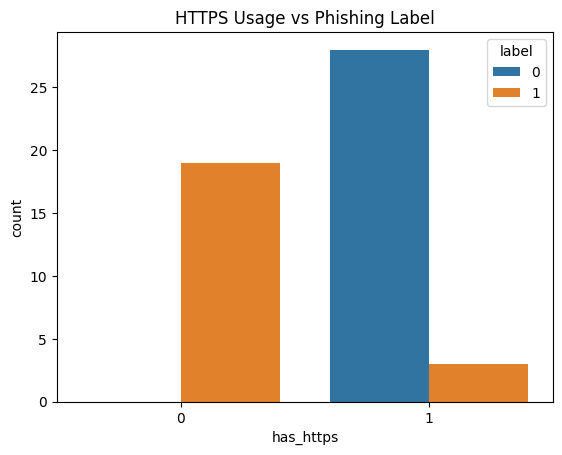

In [ ]:
plt.figure()
sns.countplot(x='has_https', hue='label', data=df)
plt.title("HTTPS Usage vs Phishing Label")
plt.show()


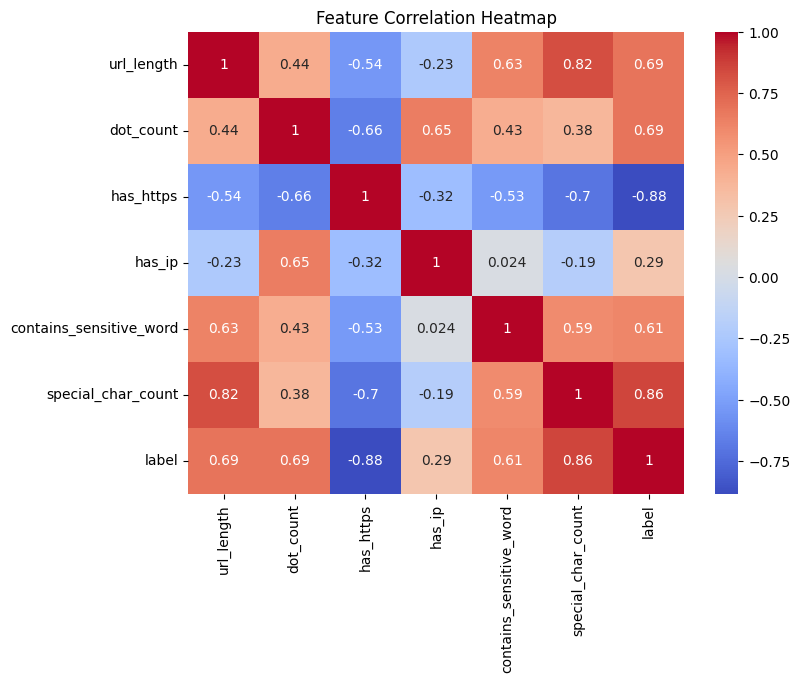

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['url_length','dot_count','has_https','has_ip','contains_sensitive_word','special_char_count','label']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


Exp 5

In [4]:
# IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# LOAD DATA
df = pd.read_csv("realistic_phishing_dataset.csv")

np.random.seed(42)

# ADD REALISTIC VARIATION

# Add noise
df['url_length'] = df['url_length'] + np.random.randint(-5, 6, size=len(df))

# Add feature
df['special_char_count'] = df['url'].str.count(r'[@\-_=]')

# Add random weak feature (IMPORTANT)
df['random_noise'] = np.random.rand(len(df))

# Flip some labels (VERY IMPORTANT)
flip_idx = df.sample(frac=0.15, random_state=42).index
df.loc[flip_idx, 'label'] = 1 - df.loc[flip_idx, 'label']

# CREATE TWO DIFFERENT FEATURE SETS

# Logistic Regression (simpler)
X_lr = df[['url_length','dot_count','has_https','random_noise']]

# Random Forest (richer features)
X_rf = df[['url_length','dot_count','has_https','has_ip',
           'contains_sensitive_word','special_char_count']]

y = df['label']

# DIFFERENT TRAIN-TEST SPLITS

# LR split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.35, random_state=2
)

# RF split (different split!)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y, test_size=0.35, random_state=10
)

# SCALE ONLY LR
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_lr)
X_test_lr = scaler.transform(X_test_lr)

# TRAIN MODELS

# Logistic Regression (weak model)
lr = LogisticRegression(max_iter=100, C=0.4)
lr.fit(X_train_lr, y_train_lr)

# Random Forest (controlled)
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_leaf=4,
    random_state=42
)
rf.fit(X_train_rf, y_train_rf)

# PREDICTIONS
y_pred_lr = lr.predict(X_test_lr)
y_pred_rf = rf.predict(X_test_rf)

# RESULTS
print("Logistic Regression\n")
print(confusion_matrix(y_test_lr, y_pred_lr))
print(classification_report(y_test_lr, y_pred_lr))

print("\nRandom Forest\n")
print(confusion_matrix(y_test_rf, y_pred_rf))
print(classification_report(y_test_rf, y_pred_rf))

# ACCURACY
print("\nAccuracy:")
print("LR:", accuracy_score(y_test_lr, y_pred_lr))
print("RF:", accuracy_score(y_test_rf, y_pred_rf))

Logistic Regression

[[6 1]
 [4 7]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71         7
           1       0.88      0.64      0.74        11

    accuracy                           0.72        18
   macro avg       0.74      0.75      0.72        18
weighted avg       0.77      0.72      0.72        18


Random Forest

[[7 0]
 [2 9]]
              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       1.00      0.82      0.90        11

    accuracy                           0.89        18
   macro avg       0.89      0.91      0.89        18
weighted avg       0.91      0.89      0.89        18


Accuracy:
LR: 0.7222222222222222
RF: 0.8888888888888888
